# iphone Sales Data Analysis Project

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("apple_products.csv")

In [3]:
df

,Product Name,Product URL,Brand,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Upc,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",https://www.flipkart.com/apple-iphone-8-plus-g...,Apple,49900,49900,0,3431,356,MOBEXRGV7EHHTGUH,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVAC6TJT4F,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVGETABXWZ,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-silver...,Apple,77000,77000,0,11202,794,MOBEXRGVMZWUHCBA,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",https://www.flipkart.com/apple-iphone-8-gold-2...,Apple,77000,77000,0,11202,794,MOBEXRGVPK7PFEJZ,4.5,2 GB
...,...,...,...,...,...,...,...,...,...,...,...
57,"APPLE iPhone SE (Black, 64 GB)",https://www.flipkart.com/apple-iphone-se-black...,Apple,29999,39900,24,95909,8161,MOBFWQ6BR3MK7AUG,4.5,4 GB
58,"APPLE iPhone 11 (Purple, 64 GB)",https://www.flipkart.com/apple-iphone-11-purpl...,Apple,46999,54900,14,43470,3331,MOBFWQ6BTFFJKGKE,4.6,4 GB
59,"APPLE iPhone 11 (White, 64 GB)",https://www.flipkart.com/apple-iphone-11-white...,Apple,46999,54900,14,43470,3331,MOBFWQ6BVWVEH3XE,4.6,4 GB
60,"APPLE iPhone 11 (Black, 64 GB)",https://www.flipkart.com/apple-iphone-11-black...,Apple,46999,54900,14,43470,3331,MOBFWQ6BXGJCEYNY,4.6,4 GB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Name         62 non-null     object 
 1   Product URL          62 non-null     object 
 2   Brand                62 non-null     object 
 3   Sale Price           62 non-null     int64  
 4   Mrp                  62 non-null     int64  
 5   Discount Percentage  62 non-null     int64  
 6   Number Of Ratings    62 non-null     int64  
 7   Number Of Reviews    62 non-null     int64  
 8   Upc                  62 non-null     object 
 9   Star Rating          62 non-null     float64
 10  Ram                  62 non-null     object 
dtypes: float64(1), int64(5), object(5)
memory usage: 5.5+ KB


In [5]:
df.isnull().sum()

Product Name           0
Product URL            0
Brand                  0
Sale Price             0
Mrp                    0
Discount Percentage    0
Number Of Ratings      0
Number Of Reviews      0
Upc                    0
Star Rating            0
Ram                    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Product Name', 'Product URL', 'Brand', 'Sale Price', 'Mrp',
       'Discount Percentage', 'Number Of Ratings', 'Number Of Reviews', 'Upc',
       'Star Rating', 'Ram'],
      dtype='object')

## 1. What are top 10 highest-rated iphones on Flipkart in india ?

In [8]:
top10=df.sort_values('Star Rating',ascending=False).head(10)
top10['Product Name']

20     APPLE iPhone 11 Pro Max (Midnight Green, 64 GB)
17         APPLE iPhone 11 Pro Max (Space Grey, 64 GB)
16    APPLE iPhone 11 Pro Max (Midnight Green, 256 GB)
15               APPLE iPhone 11 Pro Max (Gold, 64 GB)
14              APPLE iPhone 11 Pro Max (Gold, 256 GB)
0                    APPLE iPhone 8 Plus (Gold, 64 GB)
29                     APPLE iPhone 12 (White, 128 GB)
32          APPLE iPhone 12 Pro Max (Graphite, 128 GB)
35                     APPLE iPhone 12 (Black, 128 GB)
36                      APPLE iPhone 12 (Blue, 128 GB)
Name: Product Name, dtype: object

## 2. How many ratings do the highest-rated iphones have flipkart have ?

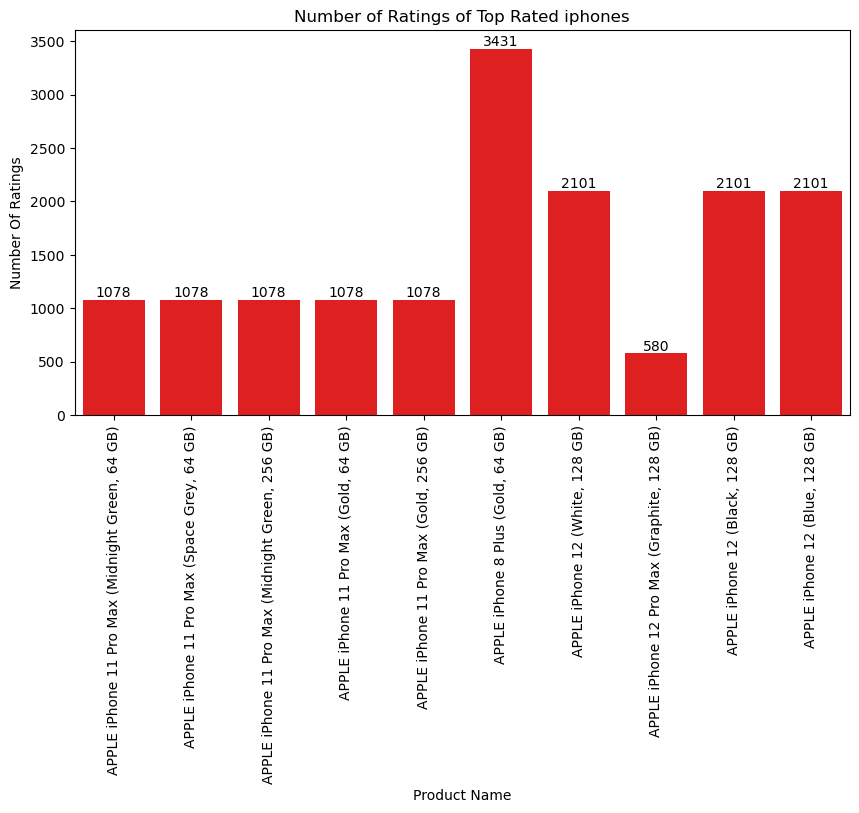

In [17]:
iphones=top10['Product Name'].value_counts()
labels=iphones.index
counts=top10['Number Of Ratings']
plt.figure(figsize=(10,5))
sns.barplot(x=labels,y=counts,data=top10,color='red')
plt.title("Number of Ratings of Top Rated iphones")
plt.xticks(rotation=90)
for i in range(len(top10)):
    plt.text(i,top10['Number Of Ratings'].iloc[i]+25,str(top10['Number Of Ratings'].iloc[i]),ha='center')
plt.savefig('top10')
plt.show()

### Conclusion:-
#### 1078 number of ratings do the highest-rated iphones have flipkart have

## 3. Which iphone has the highest number of reviews on flipkart ?

In [10]:
highest_reviews=df.loc[df['Number Of Reviews'].idxmax()]
print(highest_reviews)

Product Name           Apple iPhone SE (White, 256 GB) (Includes EarP...
Product URL            https://www.flipkart.com/apple-iphone-se-white...
Brand                                                              Apple
Sale Price                                                         44999
Mrp                                                                54900
Discount Percentage                                                   18
Number Of Ratings                                                  95909
Number Of Reviews                                                   8161
Upc                                                     MOBFRFXHPZCHAPEH
Star Rating                                                          4.5
Ram                                                                 2 GB
Name: 23, dtype: object


### Conclusion :-
#### Apple iPhone SE (White, 256 GB) has the highest number of reviews (8161) , making it the most reviewed iphone on flipkart

## 4. What is the relationship between the sale price of iphones and the numberof ratings on flipkart ?

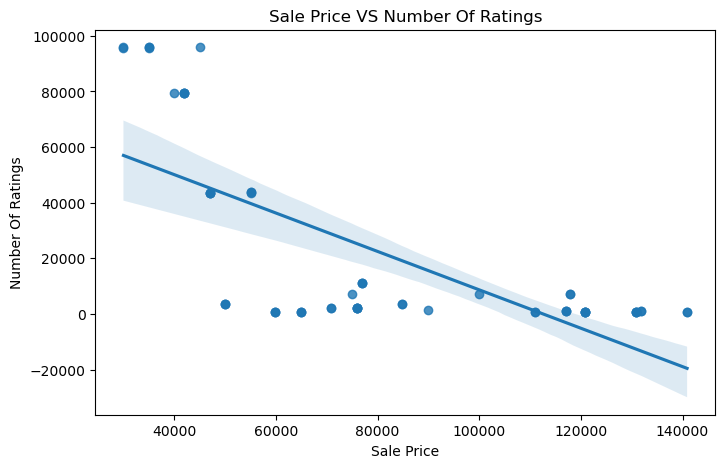

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(x='Sale Price',y='Number Of Ratings',data=df)
plt.title("Sale Price VS Number Of Ratings")
plt.savefig('saleprice_vs_number_of_ratings')
plt.show()

### Conclusion:-
#### As the sale price increases , the number of ratings generally decreases. This indicates that cheaper iphones tend to receive more ratings than expensive iphones. 

## 5. What is the relationship between the discount percentage and the numbers of ratings if iphones on flipkart ?

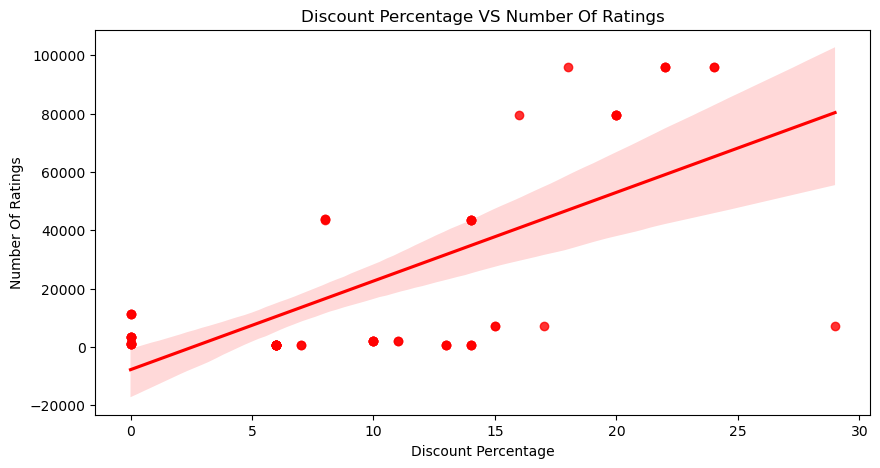

In [19]:
plt.figure(figsize=(10,5))
sns.regplot(x='Discount Percentage',y='Number Of Ratings',data=df,color='red')
plt.title("Discount Percentage VS Number Of Ratings")
plt.savefig('Discount_percentage_vs_number_of_ratings')
plt.show()

### Conclusion:-
#### There is a positive relationship between the discount percentage and number of ratings . As the discount percentage increases, the number of ratings also tend to increase. this suggest that iphones with higher discounts generally receive more customer ratings on Flipkart.

## 6. Can you figure out the least expensive and most expensive iphones in the indian market, along with all their specifications ?

### Most Expensive iphones in The Indian Market :

In [13]:
print("Most Expensive iphones in The Indian Market :") 
most_expensive=df.loc[df['Sale Price'].idxmax()]
print(most_expensive)

Most Expensive iphones in The Indian Market :
Product Name                        APPLE iPhone 12 Pro (Silver, 512 GB)
Product URL            https://www.flipkart.com/apple-iphone-12-pro-s...
Brand                                                              Apple
Sale Price                                                        140900
Mrp                                                               149900
Discount Percentage                                                    6
Number Of Ratings                                                    542
Number Of Reviews                                                     42
Upc                                                     MOBFWBYZ5UY6ZBVA
Star Rating                                                          4.5
Ram                                                                 4 GB
Name: 24, dtype: object


### Least Expensive iphones in The Indian Market :

In [14]:
least_expensive = df.loc[df['Sale Price'].idxmin()]
print(least_expensive)

Product Name                              APPLE iPhone SE (White, 64 GB)
Product URL            https://www.flipkart.com/apple-iphone-se-white...
Brand                                                              Apple
Sale Price                                                         29999
Mrp                                                                39900
Discount Percentage                                                   24
Number Of Ratings                                                  95807
Number Of Reviews                                                   8154
Upc                                                     MOBFWQ6BGWDVGF3E
Star Rating                                                          4.5
Ram                                                                 2 GB
Name: 52, dtype: object
